In [3]:
import pandas as pd

df = pd.read_csv("students.csv")

print("First 5 rows:")
print(df.head(), "\n")

print("Shape:", df.shape)
print("Data types:")
print(df.dtypes, "\n")

print("Summary statistics for numeric columns:")
print(df.describe(), "\n")

print("Count passed/failed:")
print(df["passed"].value_counts(), "\n")

subject_cols = ["math", "science", "english", "history", "pe"]
pass_mean = df[df["passed"] == 1][subject_cols].mean()
fail_mean = df[df["passed"] == 0][subject_cols].mean()

print("Average scores for passing students:")
print(pass_mean, "\n")
print("Average scores for failing students:")
print(fail_mean, "\n")

df["avg_score"] = df[subject_cols].mean(axis=1)
best_student = df.loc[df["avg_score"].idxmax()]

print("Student with highest overall average:")
print(best_student)

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0   

Shape: (15, 9)
Data types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object 

Summary statistics for numeric columns:
            math    s

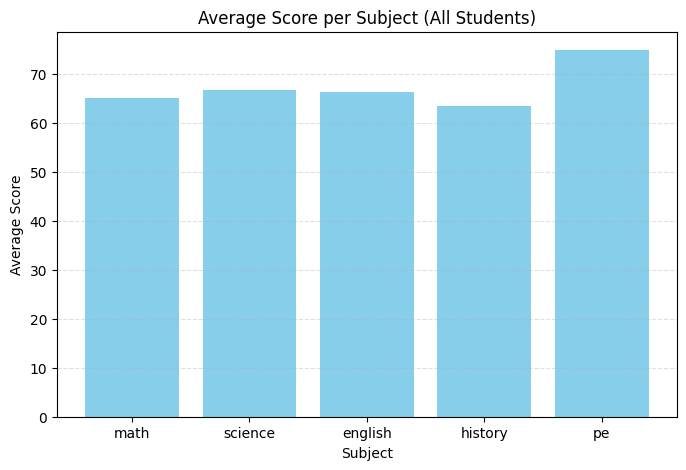

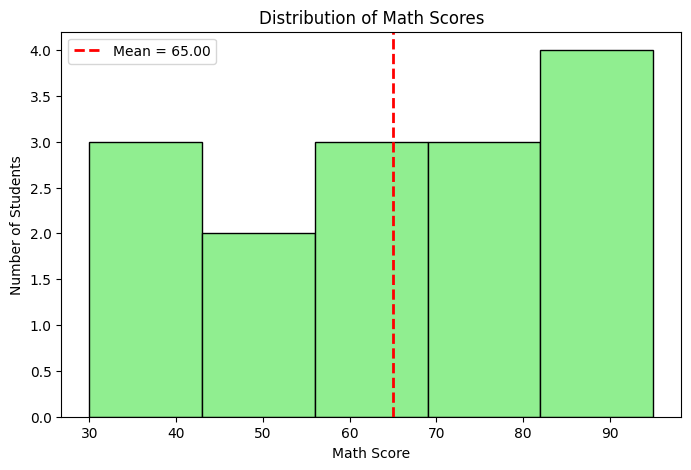

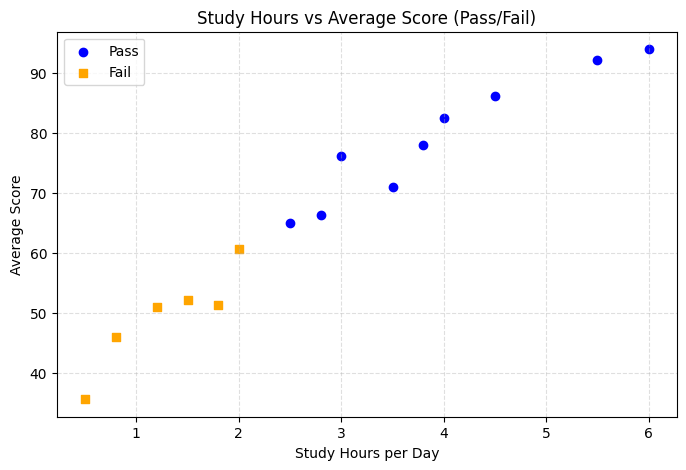

/tmp/ipykernel_8643/2197425732.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


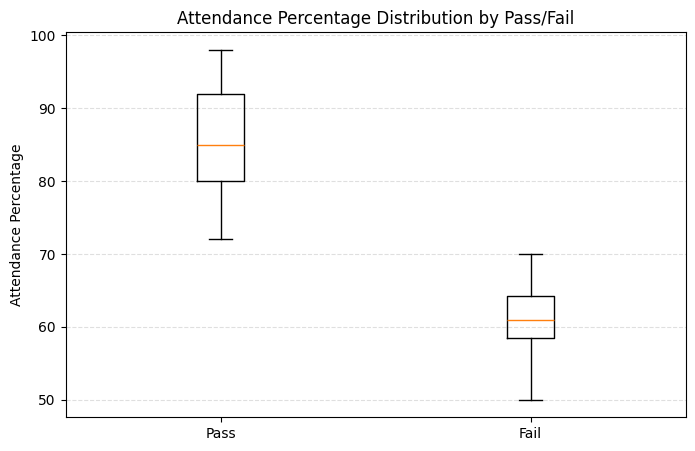

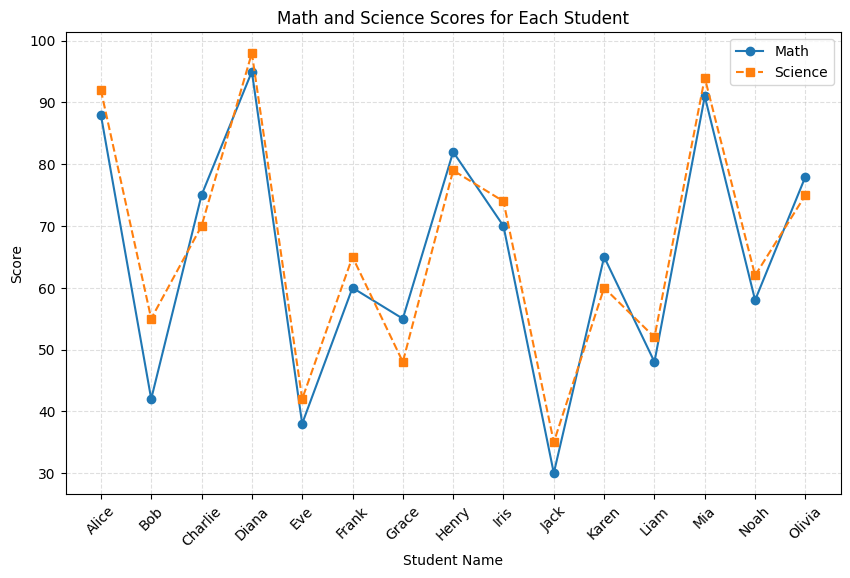

In [5]:
import matplotlib.pyplot as plt

# ensure avg_score column exists
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1) Bar chart: average score per subject
avg_subject_scores = df[subject_cols].mean()
plt.figure(figsize=(8, 5))
plt.bar(avg_subject_scores.index, avg_subject_scores.values, color='skyblue')
plt.title('Average Score per Subject (All Students)')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('plot1_bar.png', bbox_inches='tight')
plt.show()

# 2) Histogram: distribution of math scores
math_mean = df['math'].mean()
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
plt.axvline(math_mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {math_mean:.2f}')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.legend()
plt.savefig('plot2_histogram.png', bbox_inches='tight')
plt.show()

# 3) Scatter: study_hours_per_day vs avg_score colored by pass/fail
passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]
plt.figure(figsize=(8, 5))
plt.scatter(passed['study_hours_per_day'], passed['avg_score'], c='blue', marker='o', label='Pass')
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], c='orange', marker='s', label='Fail')
plt.title('Study Hours vs Average Score (Pass/Fail)')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('plot3_scatter.png', bbox_inches='tight')
plt.show()

# 4) Box plot: attendance_pct for pass vs fail
pass_attendance = passed['attendance_pct'].tolist()
fail_attendance = failed['attendance_pct'].tolist()
plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title('Attendance Percentage Distribution by Pass/Fail')
plt.ylabel('Attendance Percentage')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.savefig('plot4_boxplot.png', bbox_inches='tight')
plt.show()

# 5) Line plot: math and science scores by student
plt.figure(figsize=(10, 6))
names = df['name'].tolist()
plt.plot(names, df['math'], marker='o', linestyle='-', label='Math')
plt.plot(names, df['science'], marker='s', linestyle='--', label='Science')
plt.xticks(rotation=45)
plt.title('Math and Science Scores for Each Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('plot5_line.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_8643/1223062494.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='coolwarm')
/tmp/ipykernel_8643/1223062494.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='coolwarm')


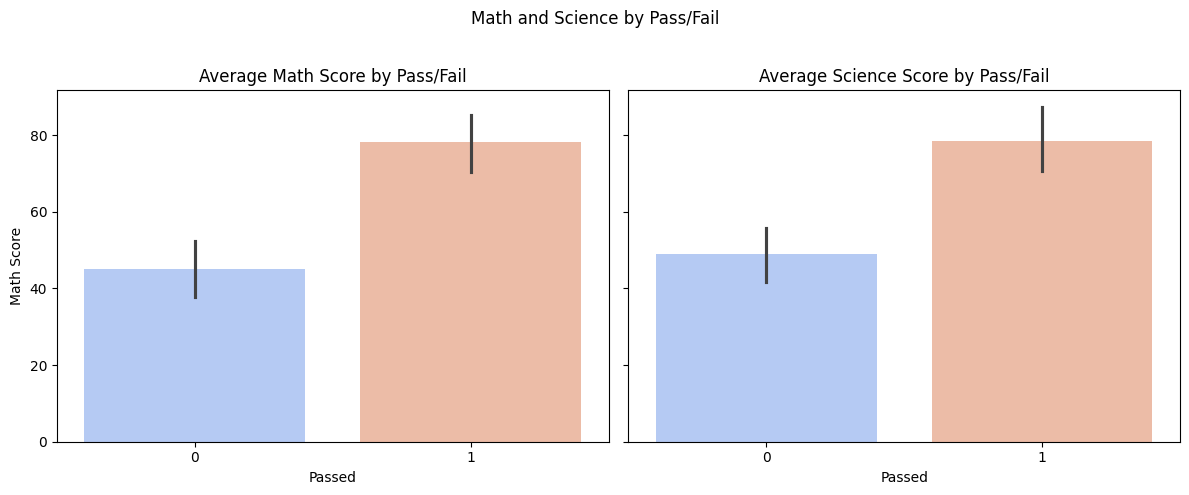

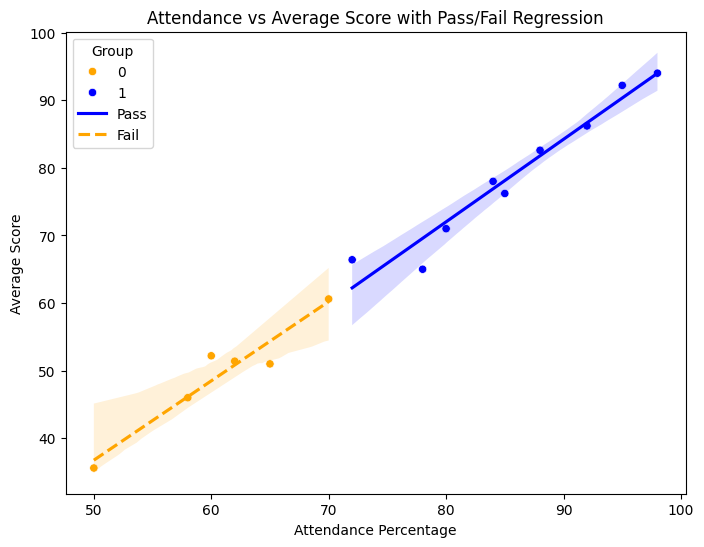

In [7]:
import seaborn as sns

# 1) Seaborn bar plots for math and science averages by pass/fail
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='coolwarm')
ax1.set_title('Average Math Score by Pass/Fail')
ax1.set_xlabel('Passed')
ax1.set_ylabel('Math Score')

sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='coolwarm')
ax2.set_title('Average Science Score by Pass/Fail')
ax2.set_xlabel('Passed')
ax2.set_ylabel('Science Score')

plt.suptitle('Math and Science by Pass/Fail')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('seaborn_bar_pass_fail.png', bbox_inches='tight')
plt.show()

# 2) Seaborn scatter with regression lines split by pass/fail
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed', palette=['orange', 'blue'], ax=ax)
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', scatter=False, ax=ax, label='Pass', color='blue', line_kws={'linestyle':'-'})
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', scatter=False, ax=ax, label='Fail', color='orange', line_kws={'linestyle':'--'})
ax.set_title('Attendance vs Average Score with Pass/Fail Regression')
ax.set_xlabel('Attendance Percentage')
ax.set_ylabel('Average Score')
ax.legend(title='Group')
fig.savefig('seaborn_scatter_regression.png', bbox_inches='tight')
plt.show()

# Comparison comment:
# Seaborn made the creation of split bar plots and combined scatter/regression plots easier by handling grouping and aesthetics automatically.
# Matplotlib required more manual setup for colors, legends, and regression lines, whereas Seaborn condensed those operations into fewer function calls.

Training accuracy: 1.000
Test accuracy: 1.000

Test set student predictions:
Jack: actual=0, predicted=0 ✅
Liam: actual=0, predicted=0 ✅
Alice: actual=1, predicted=1 ✅

Feature coefficients sorted by absolute value:
english: 0.7869 (positive impact on 'pass')
attendance_pct: 0.4517 (positive impact on 'pass')
pe: 0.3798 (positive impact on 'pass')
study_hours_per_day: 0.3713 (positive impact on 'pass')
math: 0.3598 (positive impact on 'pass')
science: 0.2208 (positive impact on 'pass')
history: 0.1041 (positive impact on 'pass')


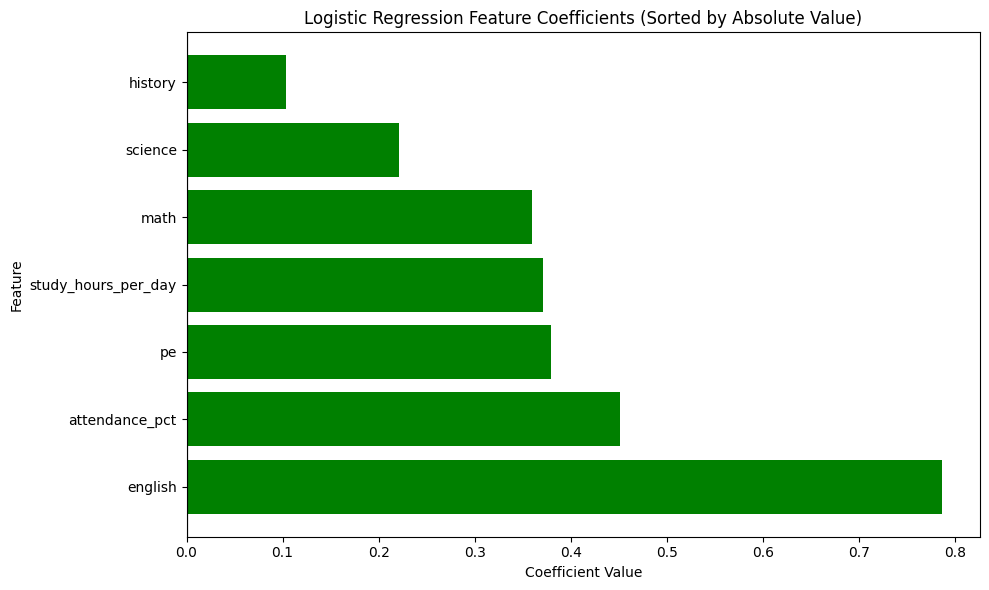


New student prediction:
Predicted: Pass (class 1)
Probability: Fail=0.228, Pass=0.772


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd # Assuming df is a pandas DataFrame

import matplotlib.pyplot as plt

# --- Assume 'df' is a pandas DataFrame loaded or created elsewhere ---
# For a runnable example, you might define a dummy DataFrame like this:
# data = {
#     'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
#     'math': [85, 60, 70, 90, 55, 75, 88, 62, 95, 68],
#     'science': [80, 65, 72, 85, 50, 70, 90, 60, 92, 70],
#     'english': [78, 70, 65, 88, 60, 72, 85, 68, 90, 75],
#     'history': [70, 55, 60, 80, 45, 68, 82, 58, 85, 62],
#     'pe': [90, 80, 75, 92, 70, 85, 95, 78, 98, 82],
#     'attendance_pct': [95, 80, 88, 98, 75, 90, 99, 82, 100, 85],
#     'study_hours_per_day': [4.0, 1.5, 2.0, 5.0, 1.0, 2.5, 4.5, 1.8, 5.5, 2.2],
#     'passed': [1, 0, 0, 1, 0, 1, 1, 0, 1, 1] # 1 for pass, 0 for fail
# }
# df = pd.DataFrame(data)
# -------------------------------------------------------------------


# Step 1 — Prepare Data
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2 — Train a Model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
print(f"Training accuracy: {train_accuracy:.3f}")

# Step 3 — Evaluate the Model
y_pred = model.predict(X_test_scaled)
test_accuracy = model.score(X_test_scaled, y_test)
print(f"Test accuracy: {test_accuracy:.3f}\n")

print("Test set student predictions:")
# Improved: Use pandas for more efficient and readable prediction display
predictions_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred
}, index=y_test.index) # Ensure indices match

# Merge with the original df to get the 'name' column
predictions_df = predictions_df.merge(df[['name']], left_index=True, right_index=True)

# Add 'correct' column
predictions_df['correct'] = predictions_df.apply(lambda row: "✅" if row['actual'] == row['predicted'] else "❌", axis=1)

for _, row in predictions_df.iterrows():
    print(f"{row['name']}: actual={row['actual']}, predicted={row['predicted']} {row['correct']}")


# Step 4 — Feature Importance
coefs = model.coef_[0]
feature_coef_pairs = list(zip(feature_cols, coefs))
feature_coef_pairs_sorted = sorted(feature_coef_pairs, key=lambda x: abs(x[1]), reverse=True)

print("\nFeature coefficients sorted by absolute value:")
for feature, coef in feature_coef_pairs_sorted:
    # More descriptive direction
    direction_impact = "positive impact on 'pass'" if coef > 0 else "negative impact on 'pass'"
    print(f"{feature}: {coef:.4f} ({direction_impact})")

# Plot coefficients (Improved: Plot features in sorted order of importance)
sorted_features = [pair[0] for pair in feature_coef_pairs_sorted]
sorted_coefs = [pair[1] for pair in feature_coef_pairs_sorted]
sorted_colors = ['green' if coef > 0 else 'red' for coef in sorted_coefs] # Recalculate colors for sorted coefs

plt.figure(figsize=(10, 6)) # Slightly larger figure for better readability
plt.barh(sorted_features, sorted_coefs, color=sorted_colors) # Use sorted data for plotting
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Feature Coefficients (Sorted by Absolute Value)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Step 5 — Predict for a New Student (Bonus)
# Improved: Use a DataFrame for new student data for better clarity and consistency
new_student_data = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=feature_cols)

new_student_scaled = scaler.transform(new_student_data)
new_pred = model.predict(new_student_scaled)[0]
new_proba = model.predict_proba(new_student_scaled)[0]

print("\nNew student prediction:")
print(f"Predicted: {'Pass' if new_pred == 1 else 'Fail'} (class {new_pred})")
print(f"Probability: Fail={new_proba[0]:.3f}, Pass={new_proba[1]:.3f}")
